In [7]:
from google.colab import files

uploaded = files.upload()
print("Uploaded files:")
print(list(uploaded.keys()))

Saving Steam Games.zip to Steam Games.zip
Uploaded files:
['Steam Games.zip']


In [8]:
import zipfile
import os

zip_path = '/content/Steam Games.zip'
extract_path = '/content/steam_games'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
for file in os.listdir(extract_path):
    print(file)

Extracted files:
steamspy_raw.csv
steam_games_wikidata.csv
extended_steam_games.csv


In [9]:
import glob
csv_files = glob.glob('/content/steam_games/**/*.csv', recursive=True)
print("CSV files:")
for i, file in enumerate(csv_files):
    print(f"{i}: {file}")

CSV files:
0: /content/steam_games/steamspy_raw.csv
1: /content/steam_games/steam_games_wikidata.csv
2: /content/steam_games/extended_steam_games.csv


In [10]:
import pandas as pd
import glob
import os
csv_files = glob.glob('/content/steam_games/**/*.csv', recursive=True)
print("Available CSV files:\n")

for i, file in enumerate(csv_files):
    print(f"{i} → {os.path.basename(file)}")

Available CSV files:

0 → steamspy_raw.csv
1 → steam_games_wikidata.csv
2 → extended_steam_games.csv


In [11]:
dataset_path = '/content/steam_games/extended_steam_games.csv'
df = pd.read_csv(dataset_path)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (23100, 28)


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,...,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,...,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,...,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,...,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,...,"Fight, farm, build and work alongside mysterio...","English, Simplified Chinese, Traditional Chine...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-..."
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,...,Nine distinct classes provide a broad range of...,"English<strong>*</strong>, Danish, Dutch, Finn...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."


In [12]:
print("Columns:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()

Columns:
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23100 entries, 0 to 23099
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                23100 non-null  int64  
 1   name                 23099 non-null  object 
 2   developer            23034 non-null  object 
 3   publisher            22967 non-null  object 
 4   positive             23100 non-null  int64  
 5   negative             23100 non-null  int64  
 6   owners               23100 non-null  o

In [13]:
print(df.isnull().sum())

appid                      0
name                       1
developer                 66
publisher                133
positive                   0
negative                   0
owners                     0
average_forever            0
average_2weeks             0
median_forever             0
median_2weeks              0
price                      0
initialprice               0
discount                   0
ccu                        0
release_date             102
required_age              48
is_free                   48
short_description         67
supported_languages       63
platforms_windows         48
platforms_mac             48
platforms_linux           48
metacritic_score       19394
recommendations           48
achievements              48
genres                   109
categories               148
dtype: int64


In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,23100.0,NaN,NaN,NaN,1105209.576147,799863.877084,10.0,433315.0,927555.0,1591632.5,3738180.0
name,23099,22541,F.E.A.R.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,23034,15155,"KOEI TECMO GAMES CO., LTD.",69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,22967,12060,Ubisoft,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positive,23100.0,NaN,NaN,NaN,5401.015671,63023.259201,0.0,49.0,286.0,1304.0,7642084.0
negative,23100.0,NaN,NaN,NaN,878.511515,11964.986824,0.0,15.0,75.0,264.0,1173003.0
owners,23100,12,"20,000 .. 50,000",8067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_forever,23100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
average_2weeks,23100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
median_forever,23100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
print("Dataset Shape:", df.shape)
print("\nColumns and Data Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (23100, 28)

Columns and Data Types:
appid                    int64
name                    object
developer               object
publisher               object
positive                 int64
negative                 int64
owners                  object
average_forever          int64
average_2weeks           int64
median_forever           int64
median_2weeks            int64
price                    int64
initialprice             int64
discount                 int64
ccu                      int64
release_date            object
required_age           float64
is_free                 object
short_description       object
supported_languages     object
platforms_windows       object
platforms_mac           object
platforms_linux         object
metacritic_score       float64
recommendations        float64
achievements           float64
genres                  object
categories              object
dtype: object

First 5 Rows:


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,...,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,...,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,...,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,...,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,...,"Fight, farm, build and work alongside mysterio...","English, Simplified Chinese, Traditional Chine...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-..."
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,...,Nine distinct classes provide a broad range of...,"English<strong>*</strong>, Danish, Dutch, Finn...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."


In [16]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'required_age', 'metacritic_score', 'recommendations', 'achievements']

Categorical Columns:
['name', 'developer', 'publisher', 'owners', 'release_date', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'genres', 'categories']


In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns having missing values:")
print(missing)

Columns having missing values:
metacritic_score       19394
categories               148
publisher                133
genres                   109
release_date             102
short_description         67
developer                 66
supported_languages       63
platforms_linux           48
required_age              48
is_free                   48
platforms_windows         48
achievements              48
platforms_mac             48
recommendations           48
name                       1
dtype: int64


In [18]:
target = 'price'
print("Target column exists:", target in df.columns)
X = df.drop(columns=[target])
y = df[target]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Target column exists: True
Features shape: (23100, 27)
Target shape: (23100,)


In [19]:
X = df.select_dtypes(include=['int64', 'float64']).copy()
if target in X.columns:
    X = X.drop(columns=[target])

y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (23100, 14)
y shape: (23100,)

Features:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'initialprice', 'discount', 'ccu', 'required_age', 'metacritic_score', 'recommendations', 'achievements']


In [20]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values after preprocessing:")
print(X.isnull().sum().sum())

Missing values after preprocessing:
0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (18480, 14)
Testing data: (4620, 14)


In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [23]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[ 399.  499.  999.  199.  699.  699. 2999. 1999. 1999.  299.]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
MAE  : 1.8895086580086577
RMSE : 30.526180790560893
R²   : 0.9991898483160112


In [25]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

display(results.head(20))

,Actual Price,Predicted Price
0,399,399.0
1,499,499.0
2,999,999.0
3,199,199.0
4,699,699.0
5,699,699.0
6,2999,2999.0
7,1999,1999.0
8,1999,1999.0
9,299,299.0


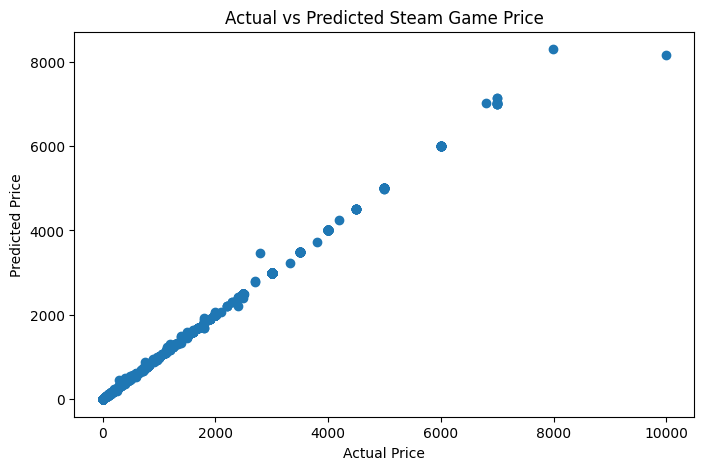

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Steam Game Price")

plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
display(importance)

Feature Importance:


,Feature,Importance
7,initialprice,0.864473
8,discount,0.134009
13,achievements,0.000441
1,positive,0.000390
0,appid,0.000282
2,negative,0.000239
9,ccu,0.000070
12,recommendations,0.000058
11,metacritic_score,0.000031
10,required_age,0.000007


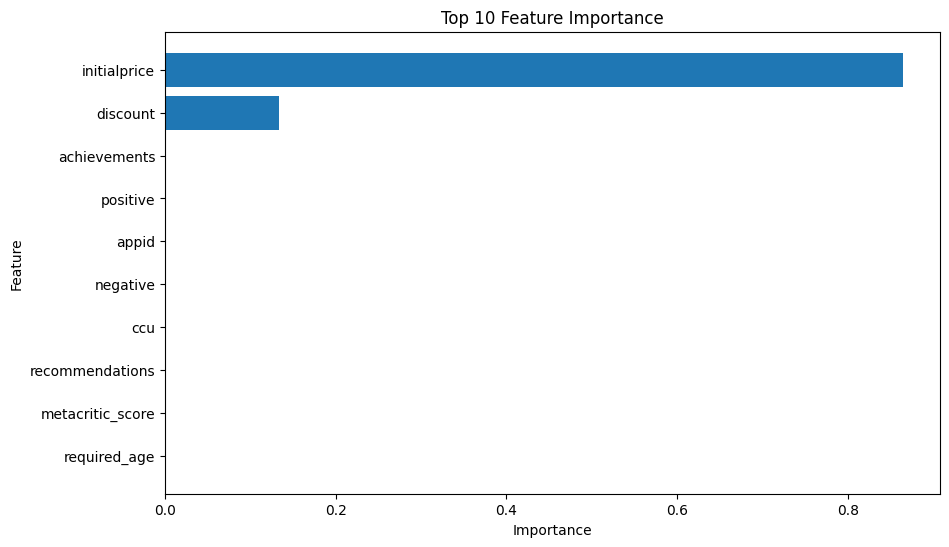

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'].head(10)[::-1],
    importance['Importance'].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")

plt.show()

In [29]:
import joblib

joblib.dump(model, '/content/steam_price_model.pkl')

print("Model saved successfully!")
print("/content/steam_price_model.pkl")

Model saved successfully!
/content/steam_price_model.pkl


In [30]:
loaded_model = joblib.load('/content/steam_price_model.pkl')

test_prediction = loaded_model.predict(X_test)

print("Model loaded successfully!")
print("First 5 predictions:")
print(test_prediction[:5])

Model loaded successfully!
First 5 predictions:
[399. 499. 999. 199. 699.]
